Implement Resnet: https://arxiv.org/pdf/1512.03385.pdf

In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
# import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
class ScaleToUnit(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = x / 255.0
        return x

train_tfs = tvt.Compose([
    tvt.PILToTensor(),
    # tvt.RandomResizedCrop((128,128), antialias=True),
    # tv2.ToDtype(torch.float32, True),
    ScaleToUnit(),
    tvt.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    tvt.RandomHorizontalFlip(0.5),
    tvt.RandomAffine(
        degrees=10,
        shear=5,
        scale=(0.8, 1.2),
    ),
])

val_tfs = tvt.Compose([
    tvt.PILToTensor(),
    # tvt.Resize((128,128), antialias=True),
    # tv2.ToDtype(torch.float32, scale=True),
    ScaleToUnit()
])

def transform(image):
    image = tvf.pil_to_tensor(image)
    image = image / 255
    return image

def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=train_tfs,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=val_tfs,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


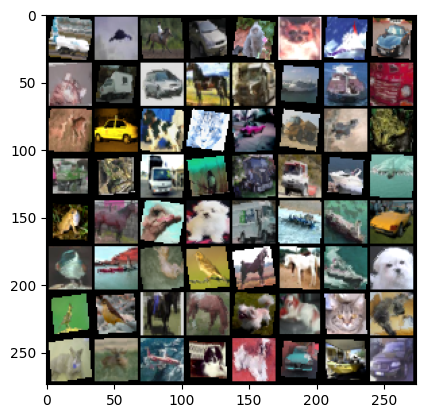

In [4]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(cifar_train, k=num)])
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())
del augmented
del tmps

In [5]:
batchsize = 128

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [6]:
class ResUnit(nn.Module):
    def __init__(self, channels, downsample=False):
        super().__init__()
        channels_out = channels*2 if downsample else channels;
        layer1_stride = 2 if downsample else 1;

        self.downsample = downsample
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        
        self.conv2 = nn.Conv2d(channels, channels_out, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(channels_out)

        if downsample:
            self.conv_d = nn.Conv2d(channels, channels_out, kernel_size=1, stride=1)
            self.bn_d = nn.BatchNorm2d(channels_out)

    def forward(self, x):
        xid = x
        x = self.conv1(x)
        x = F.relu(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.bn2(x)
        if self.downsample:
            xid = self.conv_d(xid)
            xid = F.relu(xid)
            xid = self.bn_d(xid)

        x += xid
        if self.downsample:
            x = F.max_pool2d(x, kernel_size=2)
        
        return x

class ResNet(nn.Module):
    def __init__(self, out_sz=11, ch=32):
        super().__init__()

        self.ch = ch
        self.out_sz = out_sz

        self.conv_i = nn.Conv2d(3, ch, kernel_size=7, stride=2, padding=3)
        self.bn_i = nn.BatchNorm2d(ch)

        self.l1_1 = ResUnit(ch, False)
        self.l1_2 = ResUnit(ch, False)
        self.l2_1 = ResUnit(ch, True)
        self.l2_2 = ResUnit(ch*2, False)
        self.l3_1 = ResUnit(ch*2, True)
        self.l3_2 = ResUnit(ch*4, False)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc0 = nn.Linear(ch*4, out_sz)

    def forward(self, x):
        x = self.conv_i(x)
        x = F.relu(x)
        x = self.bn_i(x)

        x = self.l1_1(x)
        x = self.l1_2(x)
        x = self.l2_1(x)
        x = self.l2_2(x)
        x = self.l3_1(x)
        x = self.l3_2(x)

        x = self.avgpool(x)
        x = self.fc0(x.view(-1, self.ch*4))
        
        x = F.softmax(x, dim=-1)
        
        return x

In [7]:
from torchinfo import summary
testmodel = ResNet(10, 64)
summary(testmodel, (1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 128, 128]         9,472
├─BatchNorm2d: 1-2                       [1, 64, 128, 128]         128
├─ResUnit: 1-3                           [1, 64, 128, 128]         --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         36,928
│    └─BatchNorm2d: 2-2                  [1, 64, 128, 128]         128
│    └─Conv2d: 2-3                       [1, 64, 128, 128]         36,928
│    └─BatchNorm2d: 2-4                  [1, 64, 128, 128]         128
├─ResUnit: 1-4                           [1, 64, 128, 128]         --
│    └─Conv2d: 2-5                       [1, 64, 128, 128]         36,928
│    └─BatchNorm2d: 2-6                  [1, 64, 128, 128]         128
│    └─Conv2d: 2-7                       [1, 64, 128, 128]         36,928
│    └─BatchNorm2d: 2-8                  [1, 64, 128, 128]    

100%|████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:03<00:00, 101.70it/s]


Epoch 0: 2.0631191730499268 
Current LR is [0.015242118714710956]
3754/10000 correct, 37.54%


100%|█████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:03<00:00, 99.62it/s]


Epoch 1: 2.0444955825805664 
Current LR is [0.04370242347569156]
4049/10000 correct, 40.49%


 72%|████████████████████████████████████████████████████████████████▍                        | 283/391 [00:02<00:01, 97.44it/s]

CPU times: user 7.12 s, sys: 1.61 s, total: 8.73 s
Wall time: 12.6 s


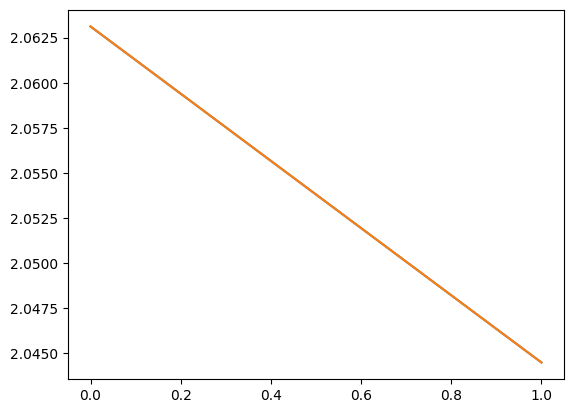

In [8]:
%%time

model = ResNet(out_sz=10, ch=64).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
epochs = 30
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    pct_start=0.15,
    steps_per_epoch=len(train_loader),
    epochs=epochs)

lossfn = nn.CrossEntropyLoss()
loss_plot = []
try:
    for epoch in range(epochs):
        model.train()
        for i, (images, target) in enumerate(tqdm(train_loader)):
            optimizer.zero_grad()
            images = images.float().to(device)
            targets = target.float().to(device)
    
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 10))
            loss.backward()
            optimizer.step()
            scheduler.step()
    
        losses = []
        model.eval()
        correct = 0
        total = len(cifar_eval)
        for i, (images, target) in enumerate(val_loader):
            with torch.no_grad():
                images = images.float().to(device)
                targets = target.float().to(device)
                outs = model(images)
    
                loss = lossfn(outs, targets.view(-1, 10))
                losses.append(loss)
                for x in range(outs.shape[0]):
                    if torch.allclose(outs[x].round().cpu(), targets.view(-1, 10)[x].cpu()):
                        correct += 1
                    
        epoch_loss = torch.Tensor(losses).mean().item()
        print("Epoch {}: {} ".format(epoch, epoch_loss))
        print("Current LR is {}".format(scheduler.get_last_lr()))
        print("{}/{} correct, {:.2f}%".format(correct, total, 100*correct/total))
        loss_plot.append(epoch_loss)
        # scheduler.step()
        
except KeyboardInterrupt:
    plt.plot(loss_plot)
plt.plot(loss_plot)